In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Step 3: Load dataset
df = pd.read_csv("Dark Side of Social Media.csv")
print("Shape:", df.shape)
df.head()


Shape: (1000, 31)


,UserID,Age,Gender,Location,Income,Debt,Owns Property,Profession,Demographics,Platform,...,ProductivityLoss,Satisfaction,Watch Reason,DeviceType,OS,Watch Time,Self Control,Addiction Level,CurrentActivity,ConnectionType
0,1,56,Male,Pakistan,82812,True,True,Engineer,Rural,Instagram,...,3,7,Procrastination,Smartphone,Android,9:00 PM,5,5,Commuting,Mobile Data
1,2,46,Female,Mexico,27999,False,True,Artist,Urban,Instagram,...,5,5,Habit,Computer,Android,5:00 PM,7,3,At school,Wi-Fi
2,3,32,Female,United States,42436,False,True,Engineer,Rural,Facebook,...,6,4,Entertainment,Tablet,Android,2:00 PM,8,2,At home,Mobile Data
3,4,60,Male,Barzil,62963,True,False,Waiting staff,Rural,YouTube,...,3,7,Habit,Smartphone,Android,9:00 PM,5,5,Commuting,Mobile Data
4,5,25,Male,Pakistan,22096,False,True,Manager,Urban,TikTok,...,8,2,Boredom,Smartphone,iOS,8:00 AM,10,0,At home,Mobile Data


In [4]:
# Step 4: Preprocess

import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# --- 1. Select features and target ---
features = ["Total Time Spent", "Self Control", "Addiction Level", "CurrentActivity"]
target = "ProductivityLoss"

# --- 2. Handle categorical variable ---
le = LabelEncoder()
df = df.copy()  # make sure we're working with a copy of the original dataframe
df["CurrentActivity_enc"] = le.fit_transform(df["CurrentActivity"])

# --- 3. Create target classes (Low, Medium, High) if not already ---
df["ProdClass"] = pd.qcut(df[target], q=3, labels=["Low", "Medium", "High"])

# --- 4. Prepare X and y ---
X = df[["Total Time Spent", "Self Control", "Addiction Level", "CurrentActivity_enc"]].copy()
y = df["ProdClass"]

# --- 5. Scale numeric features ---
scaler = StandardScaler()
numeric_features = ["Total Time Spent", "Self Control", "Addiction Level"]
X[numeric_features] = scaler.fit_transform(X[numeric_features])

# --- 6. Ready for model training ---
print("Preprocessing completed. Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)


Preprocessing completed. Feature matrix X shape: (1000, 4)
Target vector y shape: (1000,)


In [12]:
df = df.copy()

# Encode categorical variable
le = LabelEncoder()
df["CurrentActivity_enc"] = le.fit_transform(df["CurrentActivity"])

# Create target classes (Low, Medium, High)
df["ProdClass"] = pd.qcut(df["ProductivityLoss"], q=3, labels=["Low", "Medium", "High"])

# Prepare feature matrix X and target y
X = df[["Total Time Spent", "Self Control", "Addiction Level", "CurrentActivity_enc"]].copy()
y = df["ProdClass"]

# Scale numeric features
scaler = StandardScaler()
numeric_cols = ["Total Time Spent", "Self Control", "Addiction Level"]
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [13]:
# Step 6: Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Test Accuracy: 0.995
              precision    recall  f1-score   support

        High       1.00      0.98      0.99        48
         Low       1.00      1.00      1.00        71
      Medium       0.99      1.00      0.99        81

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



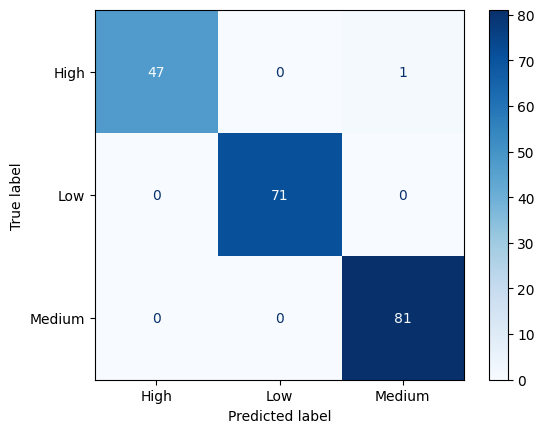

In [14]:
y_pred = rf.predict(X_test)

# Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.show()


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring="accuracy")
print("Cross-validation accuracies:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())


Cross-validation accuracies: [0.995 0.99  1.    1.    1.   ]
Mean CV accuracy: 0.9969999999999999


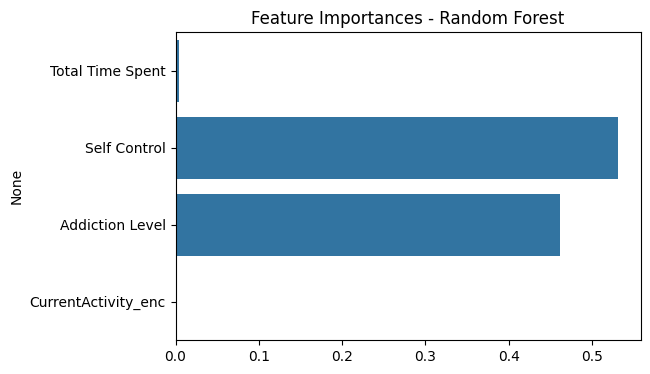

In [16]:
importances = rf.feature_importances_
features_list = X.columns

plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=features_list)
plt.title("Feature Importances - Random Forest")
plt.show()


In [17]:
def predict_productivity(new_user, rf_model, le_encoder, scaler_obj):
    """
    Predict productivity class for a new user.
    
    new_user: dict with keys "Total Time Spent", "Self Control", "Addiction Level", "CurrentActivity"
    rf_model: trained RandomForestClassifier
    le_encoder: fitted LabelEncoder for CurrentActivity
    scaler_obj: fitted StandardScaler for numeric features
    """
    
    # Encode activity safely
    activity = new_user["CurrentActivity"]
    if activity in le_encoder.classes_:
        activity_enc = le_encoder.transform([activity])[0]
    else:
        print(f"Warning: '{activity}' is unseen. Assigning default encoding 0.")
        activity_enc = 0  # fallback encoding
    
    # Prepare DataFrame
    df_new = pd.DataFrame([[
        new_user["Total Time Spent"],
        new_user["Self Control"],
        new_user["Addiction Level"],
        activity_enc
    ]], columns=["Total Time Spent", "Self Control", "Addiction Level", "CurrentActivity_enc"])
    
    # Scale numeric features
    numeric_cols = ["Total Time Spent", "Self Control", "Addiction Level"]
    df_new[numeric_cols] = scaler_obj.transform(df_new[numeric_cols])
    
    # Predict
    pred_class = rf_model.predict(df_new)[0]
    
    return pred_class

# Example usage
new_user_data = {
    "Total Time Spent": 5.0,
    "Self Control": 3.5,
    "Addiction Level": 2.0,
    "CurrentActivity": "Social Media"  # could be unseen
}

predicted_class = predict_productivity(new_user_data, rf, le, scaler)
print("Predicted Productivity Class:", predicted_class)

Predicted Productivity Class: Low


In [18]:
new_user_data = {
    "Total Time Spent": 120,   # example numeric value
    "Self Control": 7,         # example numeric value
    "Addiction Level": 3,      # example numeric value
    "CurrentActivity": "At work"  # must be from known_activities
}

# Predict using the function from before
predicted_class = predict_productivity(new_user_data, rf, le, scaler)
print("Predicted Productivity Class:", predicted_class)


Predicted Productivity Class: Medium


In [19]:
import random

# Known activities
known_activities = ["Commuting", "At school", "At home", "At work"]

# Generate 20 new users
new_users = []
for i in range(20):
    user = {
        "Total Time Spent": random.randint(20, 300),       # minutes
        "Self Control": random.randint(1, 10),
        "Addiction Level": random.randint(0, 10),
        "CurrentActivity": random.choice(known_activities)
    }
    new_users.append(user)

# Predict productivity for all 20 users
for idx, user_data in enumerate(new_users, start=1):
    pred_class = predict_productivity(user_data, rf, le, scaler)
    print(f"User {idx}: {user_data} --> Predicted Productivity Class: {pred_class}")


User 1: {'Total Time Spent': 164, 'Self Control': 10, 'Addiction Level': 9, 'CurrentActivity': 'Commuting'} --> Predicted Productivity Class: Low
User 2: {'Total Time Spent': 189, 'Self Control': 8, 'Addiction Level': 1, 'CurrentActivity': 'At home'} --> Predicted Productivity Class: Medium
User 3: {'Total Time Spent': 158, 'Self Control': 10, 'Addiction Level': 9, 'CurrentActivity': 'Commuting'} --> Predicted Productivity Class: Low
User 4: {'Total Time Spent': 39, 'Self Control': 1, 'Addiction Level': 1, 'CurrentActivity': 'At school'} --> Predicted Productivity Class: Low
User 5: {'Total Time Spent': 37, 'Self Control': 7, 'Addiction Level': 3, 'CurrentActivity': 'At work'} --> Predicted Productivity Class: Medium
User 6: {'Total Time Spent': 184, 'Self Control': 10, 'Addiction Level': 8, 'CurrentActivity': 'At home'} --> Predicted Productivity Class: Low
User 7: {'Total Time Spent': 240, 'Self Control': 3, 'Addiction Level': 7, 'CurrentActivity': 'Commuting'} --> Predicted Producti

PredictedClass
Low       16
Medium     2
High       2
Name: count, dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_7488\1859606003.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_predictions, x="PredictedClass", palette="Set2")


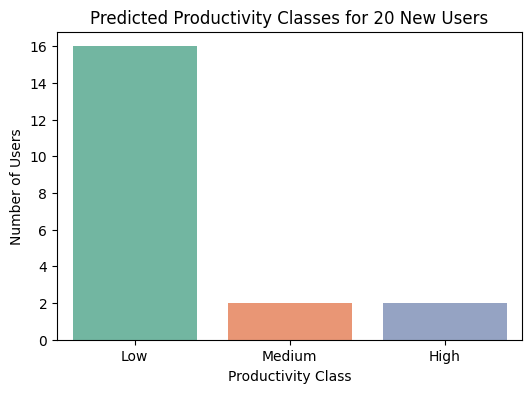

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppose new_users is your list of dictionaries
# Add predicted class to each user
predictions = []
for user_data in new_users:
    pred_class = predict_productivity(user_data, rf, le, scaler)
    user_data["PredictedClass"] = pred_class
    predictions.append(user_data)

# Convert to DataFrame
df_predictions = pd.DataFrame(predictions)

# Count of each class
class_counts = df_predictions["PredictedClass"].value_counts()
print(class_counts)

# Plot
plt.figure(figsize=(6,4))
sns.countplot(data=df_predictions, x="PredictedClass", palette="Set2")
plt.title("Predicted Productivity Classes for 20 New Users")
plt.xlabel("Productivity Class")
plt.ylabel("Number of Users")
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_7488\66469644.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_predictions, x="PredictedClass", palette="Set2")


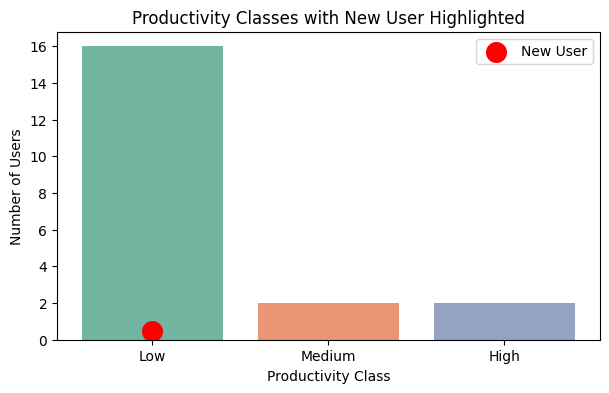

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example: existing 20 users predictions
predictions = []
for user_data in new_users:
    pred_class = predict_productivity(user_data, rf, le, scaler)
    user_data["PredictedClass"] = pred_class
    predictions.append(user_data)

# Convert to DataFrame
df_predictions = pd.DataFrame(predictions)

# New user
new_user = {
    "Total Time Spent": 150,
    "Self Control": 6,
    "Addiction Level": 4,
    "CurrentActivity": "At work"
}
new_user["PredictedClass"] = predict_productivity(new_user, rf, le, scaler)

# Plot distribution of predicted classes
plt.figure(figsize=(7,4))
sns.countplot(data=df_predictions, x="PredictedClass", palette="Set2")

# Highlight new user
plt.scatter(
    x=[new_user["PredictedClass"]], 
    y=[0.5],  # just slightly above 0 to place dot
    color='red', 
    s=200, 
    label='New User'
)

plt.title("Productivity Classes with New User Highlighted")
plt.xlabel("Productivity Class")
plt.ylabel("Number of Users")
plt.legend()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_7488\1809132488.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_predictions, x="PredictedClass", palette="Set2")


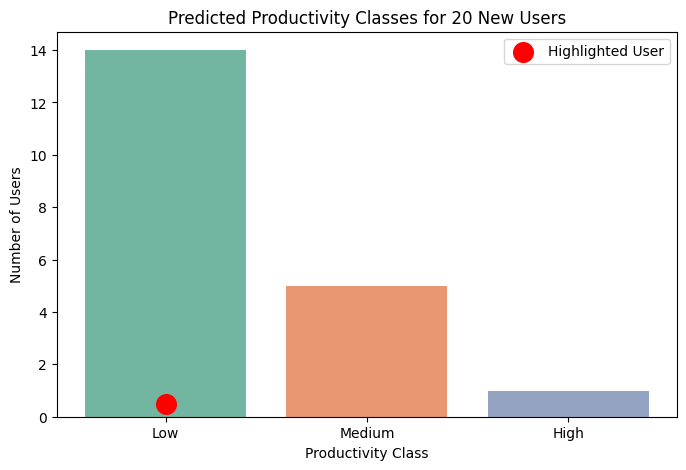

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Known activities
known_activities = ["Commuting", "At school", "At home", "At work"]

# Generate 20 new users
new_users = []
for i in range(20):
    user = {
        "Total Time Spent": random.randint(20, 300),
        "Self Control": random.randint(1, 10),
        "Addiction Level": random.randint(0, 10),
        "CurrentActivity": random.choice(known_activities)
    }
    new_users.append(user)

# Predict productivity for the 20 users
predictions = []
for user_data in new_users:
    pred_class = predict_productivity(user_data, rf, le, scaler)
    user_data["PredictedClass"] = pred_class
    predictions.append(user_data)

# Convert to DataFrame
df_predictions = pd.DataFrame(predictions)

# Optional: New user to highlight
highlight_user = {
    "Total Time Spent": 150,
    "Self Control": 6,
    "Addiction Level": 4,
    "CurrentActivity": "At work"
}
highlight_user["PredictedClass"] = predict_productivity(highlight_user, rf, le, scaler)

# Plot distribution of predicted classes
plt.figure(figsize=(8,5))
sns.countplot(data=df_predictions, x="PredictedClass", palette="Set2")

# Highlight new user
plt.scatter(
    x=[highlight_user["PredictedClass"]], 
    y=[0.5],  # slightly above 0 to make it visible
    color='red', 
    s=200, 
    label='Highlighted User'
)

plt.title("Predicted Productivity Classes for 20 New Users")
plt.xlabel("Productivity Class")
plt.ylabel("Number of Users")
plt.legend()
plt.show()


In [23]:
def suggest_improvements(new_user, model, le, scaler, X, y):
    """
    Predict productivity class and give suggestions to reduce productivity loss.
    """
    import pandas as pd
    import numpy as np

    # 1. Predict the class
    pred_class = predict_productivity(new_user, model, le, scaler)
    
    # 2. Compute average feature values for Low productivity users
    low_users = X[y == "Low"]
    low_means = low_users.mean()
    
    # Prepare user's numeric features
    user_features = pd.DataFrame({
        "Total Time Spent": [new_user["Total Time Spent"]],
        "Self Control": [new_user["Self Control"]],
        "Addiction Level": [new_user["Addiction Level"]]
    })

    # 3. Compare user to Low class averages
    suggestions = []
    if new_user["Total Time Spent"] > low_means["Total Time Spent"]:
        suggestions.append("Reduce total time spent on apps")
    if new_user["Addiction Level"] > low_means["Addiction Level"]:
        suggestions.append("Reduce addiction level / screen dependency")
    if new_user["Self Control"] < low_means["Self Control"]:
        suggestions.append("Increase self-control habits")

    # 4. Activity suggestion (optional)
    if new_user["CurrentActivity"] != "At work":
        suggestions.append("Focus activities during work hours rather than distracting activities")

    return pred_class, suggestions

# Example usage
new_user_data = {
    "Total Time Spent": 120,
    "Self Control": 7,
    "Addiction Level": 3,
    "CurrentActivity": "At work"
}

pred_class, recs = suggest_improvements(new_user_data, rf, le, scaler, X, y)
print("Predicted Productivity Class:", pred_class)
print("Suggestions to reduce productivity loss:")
for r in recs:
    print("-", r)


Predicted Productivity Class: Medium
Suggestions to reduce productivity loss:
- Reduce total time spent on apps
- Reduce addiction level / screen dependency


In [24]:
def suggest_improvements(new_user, model, le, scaler, X, y):
    """
    Predict productivity class and give suggestions to reduce productivity loss.
    """
    import pandas as pd
    import numpy as np

    # 1. Predict the class
    pred_class = predict_productivity(new_user, model, le, scaler)
    
    # 2. Compute average feature values for Low productivity users
    low_users = X[y == "Low"]
    low_means = low_users.mean()
    
    # Prepare user's numeric features
    user_features = pd.DataFrame({
        "Total Time Spent": [new_user["Total Time Spent"]],
        "Self Control": [new_user["Self Control"]],
        "Addiction Level": [new_user["Addiction Level"]]
    })

    # 3. Compare user to Low class averages
    suggestions = []
    if new_user["Total Time Spent"] > low_means["Total Time Spent"]:
        suggestions.append("Reduce total time spent on apps")
    if new_user["Addiction Level"] > low_means["Addiction Level"]:
        suggestions.append("Reduce addiction level / screen dependency")
    if new_user["Self Control"] < low_means["Self Control"]:
        suggestions.append("Increase self-control habits")

    # 4. Activity suggestion (optional)
    if new_user["CurrentActivity"] != "At work":
        suggestions.append("Focus activities during work hours rather than distracting activities")

    return pred_class, suggestions

# Example usage
new_user_data = {
    "Total Time Spent": 200,
    "Self Control": 4,
    "Addiction Level": 8,
    "CurrentActivity": "At work"
}

pred_class, recs = suggest_improvements(new_user_data, rf, le, scaler, X, y)
print("Predicted Productivity Class:", pred_class)
print("Suggestions to reduce productivity loss:")
for r in recs:
    print("-", r)


Predicted Productivity Class: Low
Suggestions to reduce productivity loss:
- Reduce total time spent on apps
- Reduce addiction level / screen dependency


In [25]:
def suggest_improvements(new_user, model, le, scaler, X, y):
    """
    Predict productivity class.
    If class is Low -> appreciation message.
    If class is Medium/High -> suggestions to reduce productivity loss.
    """
    import pandas as pd

    # 1. Predict the class
    pred_class = predict_productivity(new_user, model, le, scaler)

    # If already Low, just appreciate
    if pred_class == "Low":
        return pred_class, ["Great job! You are already maintaining low productivity loss. Keep it up! 🎉"]

    # 2. Compute average feature values for Low productivity users
    low_users = X[y == "Low"]
    low_means = low_users.mean()

    # Prepare user's numeric features
    user_features = pd.DataFrame({
        "Total Time Spent": [new_user["Total Time Spent"]],
        "Self Control": [new_user["Self Control"]],
        "Addiction Level": [new_user["Addiction Level"]]
    })

    # 3. Compare user to Low class averages
    suggestions = []
    if new_user["Total Time Spent"] > low_means["Total Time Spent"]:
        suggestions.append("Try reducing your total time spent on apps.")
    if new_user["Addiction Level"] > low_means["Addiction Level"]:
        suggestions.append("Work on reducing screen dependency and addiction level.")
    if new_user["Self Control"] < low_means["Self Control"]:
        suggestions.append("Practice habits that strengthen self-control.")

    # 4. Activity suggestion (optional)
    if new_user["CurrentActivity"] != "At work":
        suggestions.append("Consider focusing more during work hours instead of distracting activities.")

    return pred_class, suggestions


# Example usage
new_user_data = {
    "Total Time Spent": 200,
    "Self Control": 4,
    "Addiction Level": 8,
    "CurrentActivity": "At work"
}

pred_class, recs = suggest_improvements(new_user_data, rf, le, scaler, X, y)
print("Predicted Productivity Class:", pred_class)
print("Feedback:")
for r in recs:
    print("-", r)


Predicted Productivity Class: Low
Feedback:
- Great job! You are already maintaining low productivity loss. Keep it up! 🎉


In [36]:
# Example 1: High productivity loss
user_high = {
    "Total Time Spent": 240,   # very high usage
    "Self Control": 2,         # very low
    "Addiction Level": 9,      # very high
    "CurrentActivity": "Commuting"
}
pred_high, recs_high = suggest_improvements(user_high, rf, le, scaler, X, y)
print("=== High Productivity Loss User ===")
print("Predicted Class:", pred_high)
print("Feedback:")
for r in recs_high:
    print("-", r)
print("\n")


# Example 2: Medium productivity loss
user_medium = {
    "Total Time Spent": 140,   # moderate usage
    "Self Control": 6,         # okay control
    "Addiction Level": 4,      # mild addiction
    "CurrentActivity": "At home"
}
pred_medium, recs_medium = suggest_improvements(user_medium, rf, le, scaler, X, y)
print("=== Medium Productivity Loss User ===")
print("Predicted Class:", pred_medium)
print("Feedback:")
for r in recs_medium:
    print("-", r)
print("\n")


# Example 3: Low productivity loss (for comparison)
user_low = {
    "Total Time Spent": 60,    # low usage
    "Self Control": 9,         # strong control
    "Addiction Level": 2,      # very low
    "CurrentActivity": "At work"
}
pred_low, recs_low = suggest_improvements(user_low, rf, le, scaler, X, y)
print("=== Low Productivity Loss User ===")
print("Predicted Class:", pred_low)
print("Feedback:")
for r in recs_low:
    print("-", r)



=== High Productivity Loss User ===
Predicted Class: Low
Feedback:
- Great job! You are already maintaining low productivity loss. Keep it up! 🎉


=== Medium Productivity Loss User ===
Predicted Class: Low
Feedback:
- Great job! You are already maintaining low productivity loss. Keep it up! 🎉


=== Low Productivity Loss User ===
Predicted Class: High
Feedback:
- Try reducing your total time spent on apps.
- Work on reducing screen dependency and addiction level.
